In [1]:
import numpy as np
import pandas as pd
from scipy import stats


import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

# Decriptive Statistics

## 1. Quantitative data

In [2]:
# loading data csv files
df = pd.read_csv(r'quantitative_descriptive_statistics_practice.csv', index_col=0)

In [3]:
df.head()

,age,annual_income,monthly_spending,hours_sleep,study_hours_per_week,commute_minutes,exam_score
record_id,,,,,,,
1001,38,52326.0,3628.66,6.8,7.3,39,88.1
1002,25,62795.0,3312.81,7.5,5.9,40,74.2
1003,43,115436.0,3037.81,5.8,8.0,41,78.0
1004,44,121096.0,4947.10,7.3,10.4,57,83.3
1005,18,56469.0,2515.57,8.7,7.7,18,77.5


In [4]:
df.dropna(axis=0, inplace=True)

In [5]:
df.info()

<class 'pandas.DataFrame'>
Index: 443 entries, 1001 to 1450
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   age                   443 non-null    int64  
 1   annual_income         443 non-null    float64
 2   monthly_spending      443 non-null    float64
 3   hours_sleep           443 non-null    float64
 4   study_hours_per_week  443 non-null    float64
 5   commute_minutes       443 non-null    int64  
 6   exam_score            443 non-null    float64
dtypes: float64(5), int64(2)
memory usage: 27.7 KB


- **Note**- Mean is influenced by outliers but Median is not.

In [6]:
df.describe()

,age,annual_income,monthly_spending,hours_sleep,study_hours_per_week,commute_minutes,exam_score
count,443.000000,443.000000,443.000000,443.000000,443.000000,443.000000,443.000000
mean,34.943567,59545.033860,3293.895553,6.917833,8.730023,39.774266,85.859594
std,9.290630,33472.672567,1577.174137,0.929103,5.887811,20.387503,12.083859
min,18.000000,17829.000000,500.000000,4.300000,0.200000,5.000000,5.000000
25%,28.000000,40822.000000,2499.935000,6.300000,4.450000,26.000000,78.700000
50%,35.000000,54035.000000,3239.670000,6.900000,7.800000,38.000000,87.200000
75%,41.000000,69118.500000,3925.985000,7.500000,11.500000,51.500000,95.950000
max,64.000000,450000.000000,22000.000000,9.600000,36.500000,210.000000,100.000000


In [7]:
df.skew()

age                     0.212951
annual_income           5.433988
monthly_spending        5.535315
hours_sleep             0.009890
study_hours_per_week    1.411908
commute_minutes         2.164655
exam_score             -1.174145
dtype: float64

- ▶ Mean > Median : Right Skew
- ▶ Mean < Median : Left Skew
- ▶ Mean ≃ Median : Normal Distribution

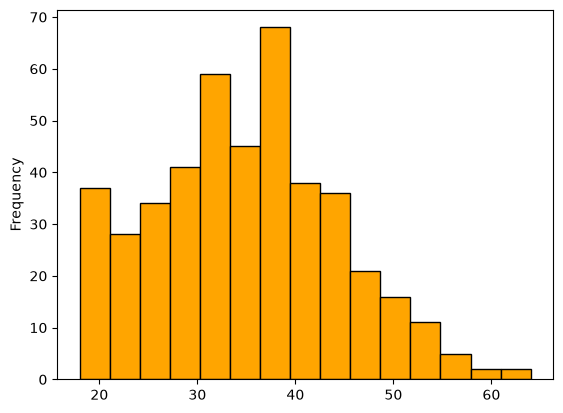

In [8]:
# plotting a histogram
df.age.plot.hist(bins=15, edgecolor='k', color='orange')
plt.show()

In [9]:
# grouping age in 5 categories

labels = ['18-24', '25-34', '35-44', '45-54', '55+']

age_groups = pd.cut(df.age, bins=5, labels=labels).value_counts()
age_groups

age
25-34    145
35-44    142
18-24     99
45-54     48
55+        9
Name: count, dtype: int64

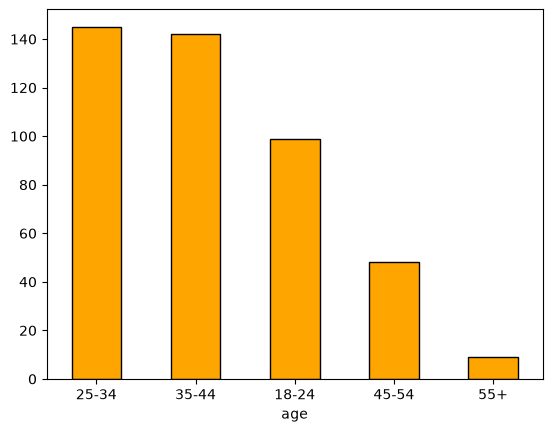

In [10]:
age_groups.plot.bar(color='orange', rot=0, edgecolor='k')
plt.show()

In [11]:
age_df = pd.DataFrame(age_groups.rename('freq'))

In [12]:
age_df['cumfreq'] = age_df.freq.cumsum()

age_df

,freq,cumfreq
age,,
25-34,145,145
35-44,142,287
18-24,99,386
45-54,48,434
55+,9,443


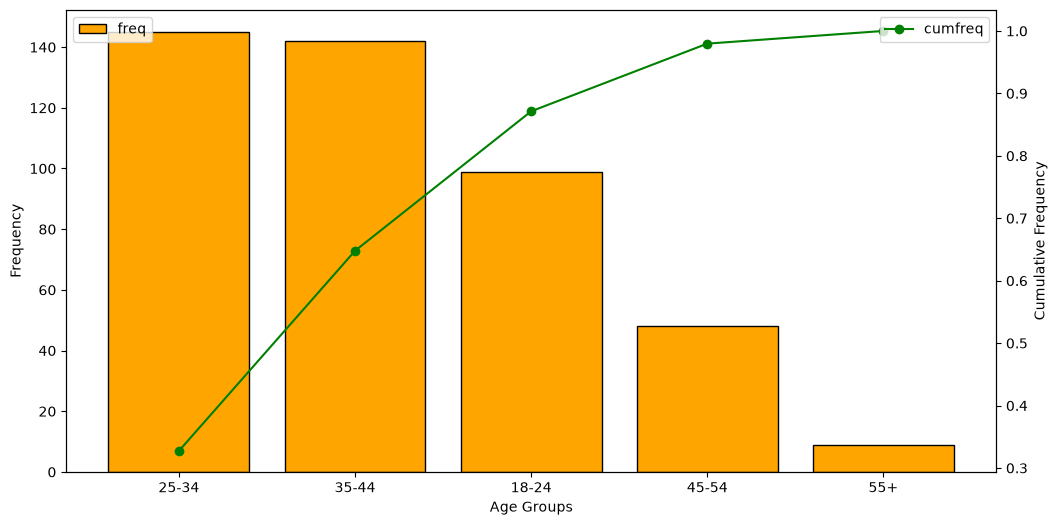

In [13]:
# plotting the ogive plot for age groups

fig, axs = plt.subplots(figsize=(12, 6))

axs.bar(x=age_df.index, height=age_df.freq, color='orange', edgecolor='k', label='freq')
ax2 = axs.twinx()
ax2.plot(age_df.index, age_df.cumfreq/age_df.freq.sum(), color='green', marker='o', label='cumfreq')
axs.set_ylabel("Frequency")
ax2.set_ylabel("Cumulative Frequency")
axs.set_xlabel("Age Groups")
axs.legend(loc='upper left')
ax2.legend(loc='upper right')
plt.show()


- **Relation Between two variables**

---
- We are going to find the relation between age and monthly spending


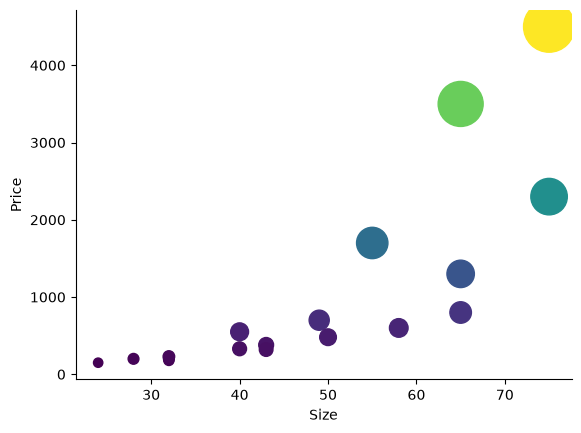

In [14]:
# we are going the find the relation between tv price and size

#### SCATTER BUBBLE PLOT #######
####================================


size = [49, 32, 50, 28, 65, 43, 75, 65, 32,
        55, 43, 24, 58, 65, 75, 32, 40, 40]

price = [700, 180, 480, 200, 800, 380, 4500, 1300, 200,
         1700, 320, 150, 600, 3500, 2300, 230, 550, 330]


plt.scatter(x=size, y=price,s=np.array(price)*0.3, c=price, cmap='viridis')
plt.xlabel('Size')
plt.ylabel('Price')
sns.despine()
plt.show()

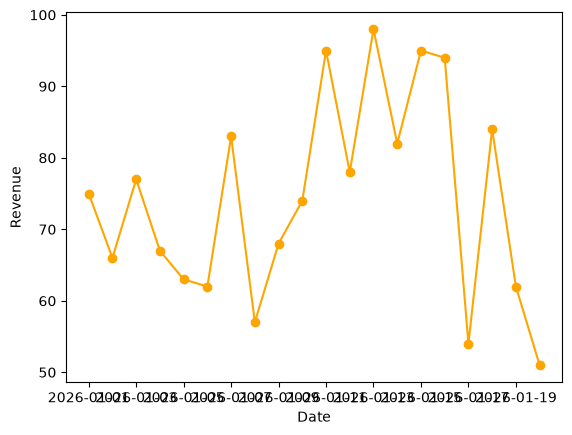

In [15]:
## line Chart

np.random.seed(11)
revenues = np.random.randint(50, 100, 20)
dates = pd.date_range(start='2026-01-01', periods=20, freq='D')


plt.plot(dates, revenues, color='orange', marker='o')
plt.xlabel('Date')
plt.ylabel('Revenue')
plt.show()

- **Coefficient of Variation**

---
Comparing the consistency between two data sets when their means are very
different is best done with the coefficient of variation. It is a useful measure because
two different data sets are likely to have different means.


In [16]:
stocks = pd.DataFrame({
    "Date": [
        "September 15, 2017",
        "October 16, 2017",
        "November 15, 2017",
        "December 15, 2017",
        "January 16, 2018",
        "February 15, 2018"
    ],
    "Nike": [
        53.87,
        51.37,
        56.63,
        64.79,
        63.42,
        67.96
    ],
    "Google": [
        935.29,
        1009.35,
        1036.41,
        1072.00,
        1130.70,
        1091.36
    ]
})

stocks = stocks.set_index('Date')
stocks

,Nike,Google
Date,,
"September 15, 2017",53.87,935.29
"October 16, 2017",51.37,1009.35
"November 15, 2017",56.63,1036.41
"December 15, 2017",64.79,1072.00
"January 16, 2018",63.42,1130.70
"February 15, 2018",67.96,1091.36


In [17]:
stocks.agg(['mean', 'std'])

,Nike,Google
mean,59.673333,1045.851667
std,6.644886,68.701357


- Since mean is different for both companies, it is better to compare their stock price consistency by using CV.

In [18]:
# coefficient of variation for both companies

cv = stocks.std()/stocks.mean()
cv

Nike      0.111354
Google    0.065689
dtype: float64

- **Even though Google’s stock price has a higher standard deviation than Nike’s does, it is more consistent because its coefficient of variation is lower.**

---



- ✈**Z-score** - Number of standard deviations a particular value is from the mean of its distribution.

- In general, data values that have z score outside of -3 to +3 are considered outliers.

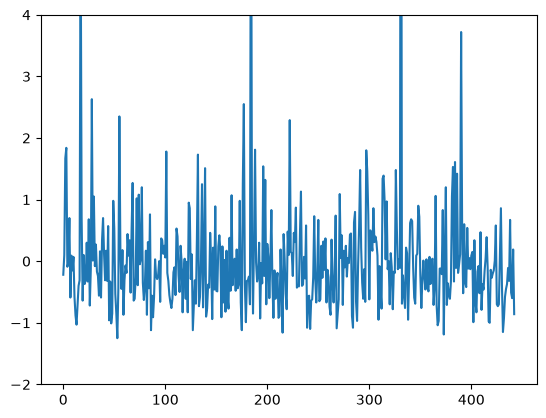

In [19]:
# zscore for annual income column

zscores = stats.zscore(df.annual_income, nan_policy='omit').round(2)
plt.plot(zscores)
plt.ylim(-2,4)
plt.show()

- Here, we can clearly see that annual income has some outliers

In [20]:
## calculating percentile for annual income columns

# 75,000 annual income percentile score
stats.percentileofscore(df.annual_income, 75000)

np.float64(81.48984198645599)

In [21]:
# percentile to value
np.percentile(df.annual_income, 81.48)

np.float64(74914.70880000001)

In [22]:
## Binning the annual income in percentile groups
labels = ['10-25', '25-50', '50-75', '75-100']
pd.qcut(df.annual_income, q=[0.1, 0.25,0.50,0.75,1], labels=labels).value_counts(normalize=True)

annual_income
25-50     0.278894
75-100    0.278894
50-75     0.276382
10-25     0.165829
Name: proportion, dtype: float64

> **Identifying outliers by using- IQR (Inter Quartile Range)**

In [ ]:
Q1 = df.annual_income.quantile(0.25)
Q3 = df.annual_income.quantile(0.75)

IQR = Q3 - Q1

upper_limit = Q3 + 1.5*IQR
lower_limit = Q1 - 1.5*IQR

df[(df.annual_income > upper_limit) | (df.annual_income < lower_limit)]

,age,annual_income,monthly_spending,hours_sleep,study_hours_per_week,commute_minutes,exam_score
record_id,,,,,,,
1003,43,115436.0,3037.81,5.8,8.0,41,78.0
1004,44,121096.0,4947.10,7.3,10.4,57,83.3
1018,25,250000.0,3782.35,8.2,8.7,69,83.4
1030,39,147592.0,3283.28,8.3,11.7,56,96.2
1057,32,137978.0,2667.57,7.2,16.0,48,100.0
1104,42,119183.0,3897.30,6.6,11.7,52,90.8
1136,25,117484.0,3198.47,6.3,7.3,35,89.2
1182,37,144905.0,3033.63,7.3,5.9,56,85.1
1189,21,320000.0,3918.57,6.2,24.7,28,100.0


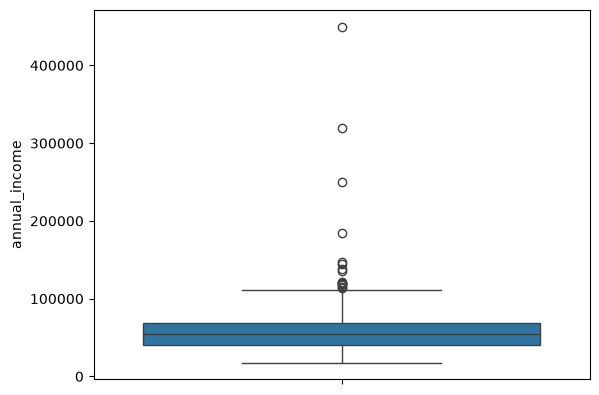

In [24]:
sns.boxplot(df.annual_income)
plt.show()

>**Correlation**

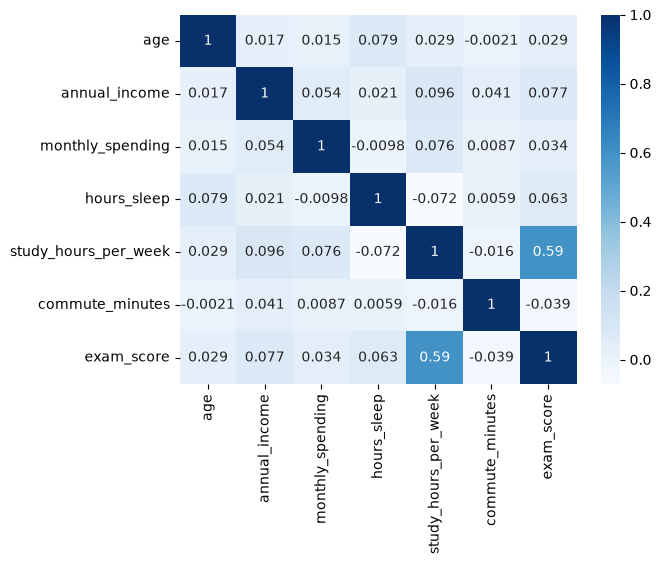

In [25]:
corr_df = df.corr()

sns.heatmap(corr_df, annot=True, cmap='Blues')
plt.show()

## 2. Categorical Data

In [26]:
cat_df = pd.read_csv(r'categorical_descriptive_statistics_practice.csv', index_col=0)
cat_df.head()

,city,gender,education_level,employment_status,device_type,membership_plan,satisfaction,newsletter,support_contacted,preferred_payment
customer_id,,,,,,,,,,
2001,Bengaluru,Female,PhD,Employed,Android,Basic,Very Dissatisfied,No,No,Net Banking
2002,Pune,Male,Master's,Student,Windows Laptop,Basic,Satisfied,Yes,No,Net Banking
2003,Jaipur,Male,Master's,Self-employed,MacBook,Basic,Neutral,Yes,No,Credit Card
2004,Jaipur,Female,Bachelor's,Employed,Android,Standard,Satisfied,Yes,No,Net Banking
2005,Mumbai,Male,Master's,Employed,Android,Standard,Very Satisfied,Yes,Yes,UPI


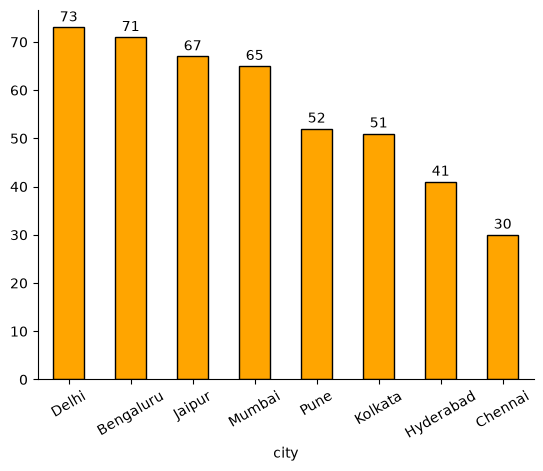

In [27]:
## Frequency plot

bars = cat_df.city.value_counts(sort=True).plot.bar(color='orange', edgecolor='k', rot=30)
for container in bars.containers:
    bars.bar_label(container, padding=2)
# removing the top and right spines
sns.despine()
plt.show()

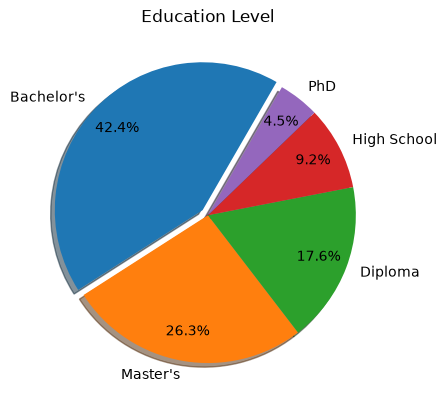

In [29]:
ed_per = cat_df.education_level.value_counts(normalize=True)

plt.pie(ed_per, explode=(0.05,0,0,0,0), shadow=True, labels=ed_per.index, startangle=60, autopct='%1.1f%%', pctdistance=0.8)
plt.title('Education Level')
# plt.legend(labels=ed_per.index, loc='best')
plt.show()

- **Contigency Tables**


---

- Contigency tales provide a format to display the frquencies of two qualitative variables.

In [30]:
cat_df.groupby(['education_level', 'gender']).size().unstack(fill_value=0)

gender,Female,Male,Non-binary
education_level,,,
Bachelor's,87,94,9
Diploma,39,36,4
High School,21,20,0
Master's,51,63,4
PhD,10,6,4
